# Planet Tanager HDF5 EDA - 20250407

Notebook nay phan tich rieng cho file:
- `Planet_Data/20250407_035527_47_4001_ortho_sr_hdf5.h5`

Muc tieu:
1. Kiem tra moi truong va GPU (CuPy uu tien, fallback NumPy)
2. Tu dong kham pha schema HDF5
3. QA/QC + thong ke + quicklook
4. Phan tich pho va red-edge
5. Tinh chi so (REP, PRI, NDLI, WBI, NDVI, PSRI)
6. Savitzky-Golay + PCA + anomaly map
7. Xuat PNG, CSV/Parquet, GeoTIFF, va markdown summary

In [1]:
from pathlib import Path
import json
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=RuntimeWarning)

ROOT = Path(r"d:\EDA_VietNam_Hyperspectral")
DATA_PATH = ROOT / "Planet_Data" / "20250407_035527_47_4001_ortho_sr_hdf5.h5"
RUN_ID = "20250407_035527_47_4001"
OUT_DIR = ROOT / "outputs" / RUN_ID
PNG_DIR = OUT_DIR / "png"
TAB_DIR = OUT_DIR / "tables"
RASTER_DIR = OUT_DIR / "rasters"
for p in [PNG_DIR, TAB_DIR, RASTER_DIR]:
    p.mkdir(parents=True, exist_ok=True)

try:
    import cupy as cp
    GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    cp = None
    GPU_AVAILABLE = False

xp = cp if GPU_AVAILABLE else np

print(f"DATA_PATH: {DATA_PATH}")
print(f"GPU_AVAILABLE: {GPU_AVAILABLE}")
print(f"Output folder: {OUT_DIR}")

DATA_PATH: d:\EDA_VietNam_Hyperspectral\Planet_Data\20250407_035527_47_4001_ortho_sr_hdf5.h5
GPU_AVAILABLE: False
Output folder: d:\EDA_VietNam_Hyperspectral\outputs\20250407_035527_47_4001


In [2]:
def walk_hdf5(path: Path):
    entries = []
    with h5py.File(path, "r") as f:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                entries.append({
                    "path": name,
                    "type": "dataset",
                    "shape": tuple(obj.shape),
                    "dtype": str(obj.dtype),
                    "attrs": {k: str(v) for k, v in obj.attrs.items()},
                })
            elif isinstance(obj, h5py.Group):
                entries.append({
                    "path": name,
                    "type": "group",
                    "shape": "",
                    "dtype": "",
                    "attrs": {k: str(v) for k, v in obj.attrs.items()},
                })
        f.visititems(visitor)
        root_attrs = {k: str(v) for k, v in f.attrs.items()}
    return entries, root_attrs


def find_first_dataset(entries, include_keywords, min_ndim=2):
    for e in entries:
        if e["type"] != "dataset":
            continue
        p = e["path"].lower()
        if all(k in p for k in include_keywords):
            shape = e["shape"]
            if isinstance(shape, tuple) and len(shape) >= min_ndim:
                return e["path"]
    return None


def select_schema(entries):
    # Candidate reflectance datasets for Planet/Tanager-like HDF5 products.
    candidates = [
        ["reflectance"],
        ["surface", "reflectance"],
        ["sr"],
        ["cube"],
        ["data"],
        ["radiance"],
    ]

    refl = None
    for keys in candidates:
        refl = find_first_dataset(entries, keys, min_ndim=3)
        if refl:
            break

    wave = None
    for keys in [["wavelength"], ["bands"], ["center", "wavelength"]]:
        wave = find_first_dataset(entries, keys, min_ndim=1)
        if wave:
            break

    mask = None
    for keys in [["mask"], ["quality"], ["qa"], ["nodata"]]:
        mask = find_first_dataset(entries, keys, min_ndim=2)
        if mask:
            break

    return {"reflectance": refl, "wavelength": wave, "mask": mask}


entries, root_attrs = walk_hdf5(DATA_PATH)
schema = select_schema(entries)

schema_df = pd.DataFrame(entries)
schema_df.to_csv(TAB_DIR / "schema_inventory.csv", index=False)
with open(OUT_DIR / "schema_root_attrs.json", "w", encoding="utf-8") as f:
    json.dump(root_attrs, f, indent=2, ensure_ascii=False)

print("Schema candidates:")
print(schema)
print(f"Inventory rows: {len(schema_df)}")

if schema["reflectance"] is None:
    raise RuntimeError("Khong tim thay dataset reflectance 3D. Kiem tra schema_inventory.csv de map lai.")

Schema candidates:
{'reflectance': 'HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance', 'wavelength': None, 'mask': 'HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask'}
Inventory rows: 21


In [3]:
def read_dataset(file_path: Path, ds_path: str):
    with h5py.File(file_path, "r") as f:
        arr = np.array(f[ds_path][...])
        attrs = {k: f[ds_path].attrs[k] for k in f[ds_path].attrs.keys()}
    return arr, attrs


def parse_attr_array(value):
    if isinstance(value, np.ndarray):
        return value.astype(np.float32).reshape(-1)
    if isinstance(value, (list, tuple)):
        return np.array(value, dtype=np.float32).reshape(-1)
    text = str(value).replace("\n", " ").replace("[", " ").replace("]", " ").replace(",", " ")
    arr = np.fromstring(text, sep=" ")
    return arr.astype(np.float32)


cube, cube_attrs = read_dataset(DATA_PATH, schema["reflectance"])
print(f"Raw cube shape: {cube.shape}, dtype: {cube.dtype}")

# Try to normalize dimensions to [bands, rows, cols].
if cube.ndim != 3:
    raise RuntimeError(f"Dataset reflectance khong phai 3D: {cube.shape}")

if cube.shape[0] < 20 and cube.shape[-1] > 20:
    cube = np.moveaxis(cube, -1, 0)
elif cube.shape[-1] < 20 and cube.shape[0] > 20:
    cube = np.moveaxis(cube, 0, -1)
    cube = np.moveaxis(cube, -1, 0)

if cube.shape[0] < 20:
    raise RuntimeError("Khong the suy ra chieu band hop le. Vui long map lai thu cong.")

cube = cube.astype(np.float32, copy=False)
scale = float(cube_attrs.get("scale_factor", 1.0)) if "scale_factor" in cube_attrs else 1.0
offset = float(cube_attrs.get("add_offset", 0.0)) if "add_offset" in cube_attrs else 0.0
cube = cube * scale + offset

nodata_candidates = ["_FillValue", "nodata", "nodata_value", "missing_value"]
nodata = None
for k in nodata_candidates:
    if k in cube_attrs:
        try:
            nodata = float(cube_attrs[k])
            break
        except Exception:
            pass

if nodata is not None:
    cube[cube == nodata] = np.nan

mask = None
if schema["mask"] is not None:
    mask, _ = read_dataset(DATA_PATH, schema["mask"])
    if mask.ndim == 3:
        mask = mask[0]
    mask = mask.astype(bool)

# Robust wavelength extraction: dataset first, then reflectance attrs, then fallback.
wavelengths = None
wavelength_source = None
if schema["wavelength"] is not None:
    wl_arr, _ = read_dataset(DATA_PATH, schema["wavelength"])
    wl_arr = np.array(wl_arr).reshape(-1).astype(np.float32)
    if wl_arr.size > 10:
        wavelengths = wl_arr
        wavelength_source = f"dataset:{schema['wavelength']}"

if wavelengths is None:
    for key in ["wavelengths", "wavelength", "bands", "band_centers", "center_wavelength"]:
        if key in cube_attrs:
            wl_arr = parse_attr_array(cube_attrs[key])
            if wl_arr.size > 10:
                wavelengths = wl_arr
                wavelength_source = f"attrs:{key}"
                break

if wavelengths is None:
    wavelengths = np.linspace(380.0, 2500.0, cube.shape[0], dtype=np.float32)
    wavelength_source = "fallback_linspace"

# Unit normalization to nm
wl_unit = str(cube_attrs.get("wavelengths_units", cube_attrs.get("wavelength_unit", ""))).lower()
if "um" in wl_unit or "mic" in wl_unit:
    wavelengths = wavelengths * 1000.0
elif np.nanmax(wavelengths) < 10:
    wavelengths = wavelengths * 1000.0

# Size alignment safeguard
if wavelengths.size != cube.shape[0]:
    x_old = np.linspace(0, 1, wavelengths.size, dtype=np.float32)
    x_new = np.linspace(0, 1, cube.shape[0], dtype=np.float32)
    wavelengths = np.interp(x_new, x_old, wavelengths).astype(np.float32)
    wavelength_source += "_resampled"

print(f"Normalized cube shape [B,H,W]: {cube.shape}")
print(f"Wavelength count: {wavelengths.size}")
print(f"Wavelength source: {wavelength_source}")
print(f"Wavelength range (nm): {float(np.nanmin(wavelengths)):.2f} -> {float(np.nanmax(wavelengths)):.2f}")
print(f"Mask present: {mask is not None}")

Raw cube shape: (426, 717, 789), dtype: float32
Normalized cube shape [B,H,W]: (426, 717, 789)
Wavelength count: 426
Wavelength source: attrs:wavelengths
Wavelength range (nm): 376.44 -> 2499.00
Mask present: True


=== DATA OVERVIEW ===
Data file: d:\EDA_VietNam_Hyperspectral\Planet_Data\20250407_035527_47_4001_ortho_sr_hdf5.h5
Cube shape [bands, rows, cols]: (426, 717, 789)
Cube dtype: float32
Wavelength range: 376.44 -> 2499.00
Finite ratio (all voxels): 0.7174
Mask coverage (True ratio): 0.0060
Reflectance min/max/mean/std: -3.274321 / 65.260399 / 0.163286 / 0.129023


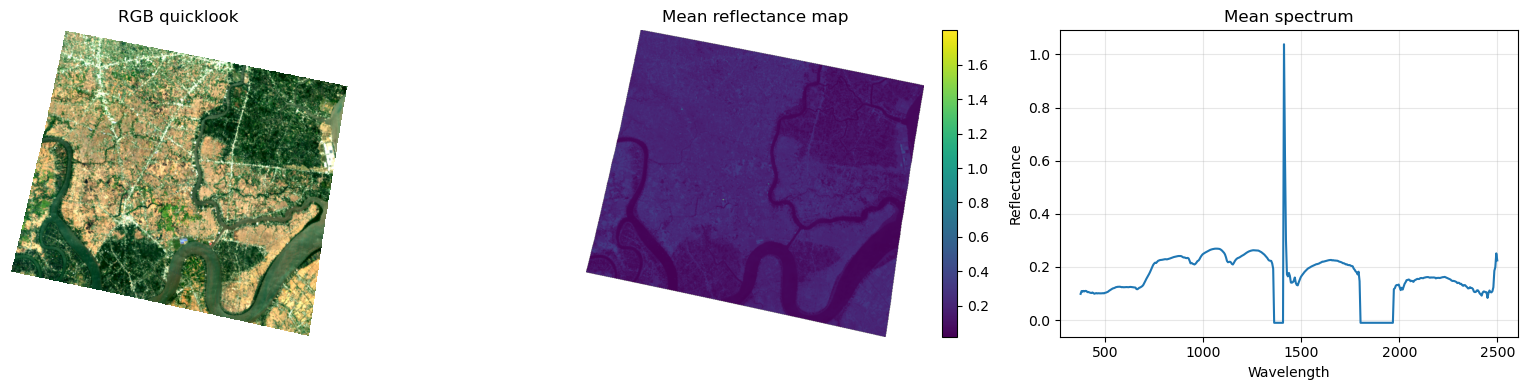

In [4]:
# Data overview (quick check)
if "cube" not in globals() or "wavelengths" not in globals():
    raise RuntimeError("Can not find cube/wavelengths. Run previous data-loading cell first.")

print("=== DATA OVERVIEW ===")
print(f"Data file: {DATA_PATH}")
print(f"Cube shape [bands, rows, cols]: {cube.shape}")
print(f"Cube dtype: {cube.dtype}")
print(f"Wavelength range: {float(np.nanmin(wavelengths)):.2f} -> {float(np.nanmax(wavelengths)):.2f}")
print(f"Finite ratio (all voxels): {float(np.isfinite(cube).mean()):.4f}")

if "mask" in globals() and mask is not None:
    print(f"Mask coverage (True ratio): {float(np.mean(mask.astype(np.float32))):.4f}")
else:
    print("Mask coverage: not available")

# Sample overall stats per cube
cube_min = float(np.nanmin(cube))
cube_max = float(np.nanmax(cube))
cube_mean = float(np.nanmean(cube))
cube_std = float(np.nanstd(cube))
print(f"Reflectance min/max/mean/std: {cube_min:.6f} / {cube_max:.6f} / {cube_mean:.6f} / {cube_std:.6f}")

# Preview maps and mean spectrum
r = int(np.argmin(np.abs(wavelengths - 665)))
g = int(np.argmin(np.abs(wavelengths - 560)))
b = int(np.argmin(np.abs(wavelengths - 490)))
rgb = np.stack([cube[r], cube[g], cube[b]], axis=-1)

p2 = np.nanpercentile(rgb, 2)
p98 = np.nanpercentile(rgb, 98)
rgb_vis = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

mean_spec = np.nanmean(cube, axis=(1, 2))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(rgb_vis)
axes[0].set_title("RGB quicklook")
axes[0].axis("off")

im = axes[1].imshow(np.nanmean(cube, axis=0), cmap="viridis")
axes[1].set_title("Mean reflectance map")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].plot(wavelengths, mean_spec)
axes[2].set_title("Mean spectrum")
axes[2].set_xlabel("Wavelength")
axes[2].set_ylabel("Reflectance")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
def nearest_band_idx(target_nm):
    return int(np.argmin(np.abs(wavelengths - float(target_nm))))


def save_fig(fig, name):
    fig.savefig(PNG_DIR / name, dpi=150, bbox_inches="tight")
    plt.close(fig)


# Basic QA/QC stats
band_mean = np.nanmean(cube, axis=(1, 2))
band_std = np.nanstd(cube, axis=(1, 2))
valid_ratio = np.isfinite(cube).mean(axis=(1, 2))

qa_df = pd.DataFrame({
    "band_index": np.arange(cube.shape[0]),
    "wavelength_nm": wavelengths,
    "mean": band_mean,
    "std": band_std,
    "valid_ratio": valid_ratio,
})
qa_df.to_csv(TAB_DIR / "qa_band_stats.csv", index=False)
qa_df.to_parquet(TAB_DIR / "qa_band_stats.parquet", index=False)

# Quicklook RGB using nearest Sentinel-like bands
r = nearest_band_idx(665)
g = nearest_band_idx(560)
b = nearest_band_idx(490)
rgb = np.stack([cube[r], cube[g], cube[b]], axis=-1)

p2 = np.nanpercentile(rgb, 2)
p98 = np.nanpercentile(rgb, 98)
rgb_vis = np.clip((rgb - p2) / (p98 - p2 + 1e-8), 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(rgb_vis)
ax[0].set_title("Quicklook RGB")
ax[0].axis("off")

ax[1].plot(wavelengths, band_mean, label="Mean")
ax[1].fill_between(wavelengths, band_mean - band_std, band_mean + band_std, alpha=0.2)
ax[1].set_title("Mean Spectrum +/- 1 std")
ax[1].set_xlabel("Wavelength (nm)")
ax[1].set_ylabel("Reflectance")
ax[1].grid(True, alpha=0.3)
save_fig(fig, "01_qaqc_rgb_and_spectrum.png")

print("Saved QA/QC outputs.")

Saved QA/QC outputs.


In [6]:
# Spectral derivative and REP estimation
mean_spec = np.nanmean(cube, axis=(1, 2))
wl_window = min(11, (len(mean_spec) // 2) * 2 - 1)
if wl_window < 5:
    wl_window = 5
mean_spec_sg = savgol_filter(mean_spec, window_length=wl_window, polyorder=2, mode="interp")

deriv = np.gradient(mean_spec_sg, wavelengths)
red_edge_mask = (wavelengths >= 680) & (wavelengths <= 780)
if np.any(red_edge_mask):
    rep_nm = float(wavelengths[red_edge_mask][np.argmax(deriv[red_edge_mask])])
else:
    rep_nm = float(wavelengths[np.argmax(deriv)])

# Extended hyperspectral indices
idx = {
    "R490": nearest_band_idx(490),
    "R510": nearest_band_idx(510),
    "R531": nearest_band_idx(531),
    "R550": nearest_band_idx(550),
    "R560": nearest_band_idx(560),
    "R570": nearest_band_idx(570),
    "R665": nearest_band_idx(665),
    "R670": nearest_band_idx(670),
    "R680": nearest_band_idx(680),
    "R700": nearest_band_idx(700),
    "R740": nearest_band_idx(740),
    "R780": nearest_band_idx(780),
    "R800": nearest_band_idx(800),
    "R819": nearest_band_idx(819),
    "R900": nearest_band_idx(900),
    "R970": nearest_band_idx(970),
    "R1510": nearest_band_idx(1510),
    "R1599": nearest_band_idx(1599),
    "R1680": nearest_band_idx(1680),
    "R1754": nearest_band_idx(1754),
    "R2000": nearest_band_idx(2000),
    "R2100": nearest_band_idx(2100),
    "R2180": nearest_band_idx(2180),
    "R2200": nearest_band_idx(2200),
    "R2300": nearest_band_idx(2300),
    "R2400": nearest_band_idx(2400),
}

R = {k: cube[v] for k, v in idx.items()}

def safe_div(a, b):
    return a / (b + 1e-8)

def safe_log_inv(x):
    x_clip = np.clip(x, 1e-6, None)
    return np.log(1.0 / x_clip)

# Existing indices
ndvi = safe_div(R["R800"] - R["R665"], R["R800"] + R["R665"])
pri = safe_div(R["R531"] - R["R570"], R["R531"] + R["R570"])
wbi = safe_div(R["R900"], R["R970"])  # water band index convention requested by user
ndli = safe_div(safe_log_inv(R["R1754"]) - safe_log_inv(R["R1680"]),
                safe_log_inv(R["R1754"]) + safe_log_inv(R["R1680"]))
psri = safe_div(R["R680"] - R["R490"], R["R800"])
rep_pixel = 700.0 + 40.0 * safe_div(((R["R670"] + R["R780"]) / 2.0) - R["R700"], R["R740"] - R["R700"])

# Pigment indices
ari = safe_div(1.0, R["R550"]) - safe_div(1.0, R["R700"])
cri550 = safe_div(1.0, R["R510"]) - safe_div(1.0, R["R550"])
cri700 = safe_div(1.0, R["R510"]) - safe_div(1.0, R["R700"])
mcari = ((R["R700"] - R["R670"]) - 0.2 * (R["R700"] - R["R550"])) * safe_div(R["R700"], R["R670"])
osavi = 1.16 * safe_div(R["R800"] - R["R670"], R["R800"] + R["R670"] + 0.16)
mcari_osavi = safe_div(mcari, osavi)

# Nitrogen/protein indices
ndni = safe_div(safe_log_inv(R["R1510"]) - safe_log_inv(R["R1680"]),
                safe_log_inv(R["R1510"]) + safe_log_inv(R["R1680"]))
protein_proxy = safe_div(R["R2180"], R["R2100"])

# Structural carbon indices
cai = 0.5 * (R["R2000"] + R["R2200"]) - R["R2100"]
lcai_part1 = safe_div(0.5 * (R["R2000"] + R["R2200"]) - R["R2100"], 0.5 * (R["R2000"] + R["R2200"]))
lcai_part2 = safe_div(0.5 * (R["R2200"] + R["R2400"]) - R["R2300"], 0.5 * (R["R2200"] + R["R2400"]))
lcai = lcai_part1 + lcai_part2

# Water/stress indices
wi = safe_div(R["R900"], R["R970"])
msi = safe_div(R["R1599"], R["R819"])

index_maps = {
    "REP": rep_pixel,
    "PRI": pri,
    "NDLI": ndli,
    "WBI": wbi,
    "NDVI": ndvi,
    "PSRI": psri,
    "ARI": ari,
    "CRI550": cri550,
    "CRI700": cri700,
    "MCARI": mcari,
    "MCARI_OSAVI": mcari_osavi,
    "NDNI": ndni,
    "PROTEIN_PROXY_2180_2100": protein_proxy,
    "CAI": cai,
    "LCAI": lcai,
    "WI": wi,
    "MSI": msi,
}

index_summary = []
for name, arr in index_maps.items():
    index_summary.append({
        "index": name,
        "mean": float(np.nanmean(arr)),
        "std": float(np.nanstd(arr)),
        "p05": float(np.nanpercentile(arr, 5)),
        "p50": float(np.nanpercentile(arr, 50)),
        "p95": float(np.nanpercentile(arr, 95)),
    })
index_df = pd.DataFrame(index_summary)
index_df.to_csv(TAB_DIR / "index_summary.csv", index=False)
index_df.to_parquet(TAB_DIR / "index_summary.parquet", index=False)

# Visualize all indices in a flexible grid
n = len(index_maps)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.6 * nrows))
axes = np.array(axes).reshape(-1)
for ax in axes[n:]:
    ax.axis("off")
for ax, (name, arr) in zip(axes, index_maps.items()):
    im = ax.imshow(arr, cmap="viridis")
    ax.set_title(name)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_fig(fig, "02_index_maps.png")

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(wavelengths, mean_spec, label="Mean")
ax.plot(wavelengths, mean_spec_sg, label="Savitzky-Golay")
ax.axvline(rep_nm, color="r", linestyle="--", label=f"REP ~ {rep_nm:.1f} nm")
ax.set_title("Spectral profile and REP")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance")
ax.legend()
ax.grid(True, alpha=0.3)
save_fig(fig, "03_spectrum_rep.png")

print(f"REP (mean-spectrum): {rep_nm:.2f} nm")
print("Extended indices:", ", ".join(index_maps.keys()))

REP (mean-spectrum): 730.97 nm
Extended indices: REP, PRI, NDLI, WBI, NDVI, PSRI, ARI, CRI550, CRI700, MCARI, MCARI_OSAVI, NDNI, PROTEIN_PROXY_2180_2100, CAI, LCAI, WI, MSI


In [7]:
# PCA + anomaly
X = np.moveaxis(cube, 0, -1).reshape(-1, cube.shape[0])
valid = np.all(np.isfinite(X), axis=1)
Xv = X[valid]

Xv_sg = savgol_filter(Xv, window_length=min(11, (cube.shape[0]//2)*2-1), polyorder=2, axis=1, mode="interp")

pca = PCA(n_components=3, random_state=42)
pcs = pca.fit_transform(Xv_sg)

pc_maps = np.full((X.shape[0], 3), np.nan, dtype=np.float32)
pc_maps[valid] = pcs.astype(np.float32)
pc_maps = pc_maps.reshape(cube.shape[1], cube.shape[2], 3)

# Anomaly score from standardized PC distance
z = (pcs - pcs.mean(axis=0)) / (pcs.std(axis=0) + 1e-8)
score = np.sqrt((z ** 2).sum(axis=1))
score_map = np.full(X.shape[0], np.nan, dtype=np.float32)
score_map[valid] = score.astype(np.float32)
score_map = score_map.reshape(cube.shape[1], cube.shape[2])

thr = np.nanpercentile(score_map, 99)
anomaly = score_map >= thr

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i in range(3):
    im = axes.ravel()[i].imshow(pc_maps[:, :, i], cmap="coolwarm")
    axes.ravel()[i].set_title(f"PC{i+1}")
    axes.ravel()[i].axis("off")
    fig.colorbar(im, ax=axes.ravel()[i], fraction=0.046, pad=0.04)
im = axes.ravel()[3].imshow(score_map, cmap="magma")
axes.ravel()[3].contour(anomaly, levels=[0.5], colors="cyan", linewidths=0.5)
axes.ravel()[3].set_title("Anomaly score (>=P99 contour)")
axes.ravel()[3].axis("off")
fig.colorbar(im, ax=axes.ravel()[3], fraction=0.046, pad=0.04)
save_fig(fig, "04_pca_anomaly.png")

anomaly_df = pd.DataFrame({
    "score": score,
})
anomaly_df.to_csv(TAB_DIR / "anomaly_scores_flat.csv", index=False)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.76797647 0.11614157 0.0642452 ]


In [8]:
# GeoTIFF export (if rasterio available)
def try_export_geotiff(name, arr2d):
    try:
        import rasterio
        from rasterio.transform import Affine

        profile = {
            "driver": "GTiff",
            "height": arr2d.shape[0],
            "width": arr2d.shape[1],
            "count": 1,
            "dtype": "float32",
            "compress": "deflate",
        }

        # Optional metadata from root attrs if present.
        transform = None
        crs = None
        for k in ["transform", "geo_transform", "geotransform"]:
            if k in root_attrs:
                vals = str(root_attrs[k]).replace("[", "").replace("]", "").split(",")
                nums = [float(v) for v in vals if v.strip()]
                if len(nums) >= 6:
                    transform = Affine(nums[1], nums[2], nums[0], nums[4], nums[5], nums[3])
                    break
        for k in ["crs", "spatial_ref", "epsg"]:
            if k in root_attrs:
                crs = str(root_attrs[k])
                break

        if transform is not None:
            profile["transform"] = transform
        if crs is not None:
            profile["crs"] = crs

        out = RASTER_DIR / f"{name}.tif"
        with rasterio.open(out, "w", **profile) as dst:
            dst.write(arr2d.astype(np.float32), 1)
        return str(out)
    except Exception as e:
        return f"skip: {e}"


raster_log = []
for name, arr in index_maps.items():
    raster_log.append({"layer": name, "result": try_export_geotiff(name, arr)})
raster_log.append({"layer": "ANOMALY_SCORE", "result": try_export_geotiff("ANOMALY_SCORE", score_map)})
for i in range(3):
    raster_log.append({"layer": f"PC{i+1}", "result": try_export_geotiff(f"PC{i+1}", pc_maps[:, :, i])})

raster_log_df = pd.DataFrame(raster_log)
raster_log_df.to_csv(TAB_DIR / "raster_export_log.csv", index=False)

summary_lines = [
    f"# EDA Summary - {RUN_ID}",
    "",
    f"- Data path: {DATA_PATH}",
    f"- Cube shape [bands, rows, cols]: {cube.shape}",
    f"- GPU available (CuPy): {GPU_AVAILABLE}",
    f"- REP mean-spectrum (nm): {rep_nm:.2f}",
    f"- PCA explained variance ratio: {pca.explained_variance_ratio_.tolist()}",
    f"- Anomaly threshold (P99): {float(thr):.4f}",
    "",
    "## Outputs",
    f"- PNG: {PNG_DIR}",
    f"- Tables: {TAB_DIR}",
    f"- Rasters: {RASTER_DIR}",
    "",
    "## Notes",
    "- Band mapping uses nearest wavelength from metadata.",
    "- If schema mismatch happens, review schema_inventory.csv and map manually.",
]

summary_md = "\n".join(summary_lines)
with open(OUT_DIR / "summary.md", "w", encoding="utf-8") as f:
    f.write(summary_md)

print(summary_md)
print("Done.")

c:\Users\ADMIN\anaconda3\envs\plantgpu\lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


# EDA Summary - 20250407_035527_47_4001

- Data path: d:\EDA_VietNam_Hyperspectral\Planet_Data\20250407_035527_47_4001_ortho_sr_hdf5.h5
- Cube shape [bands, rows, cols]: (426, 717, 789)
- GPU available (CuPy): False
- REP mean-spectrum (nm): 730.97
- PCA explained variance ratio: [0.7679764735586226, 0.1161415675690015, 0.06424520353001979]
- Anomaly threshold (P99): 3.2837

## Outputs
- PNG: d:\EDA_VietNam_Hyperspectral\outputs\20250407_035527_47_4001\png
- Tables: d:\EDA_VietNam_Hyperspectral\outputs\20250407_035527_47_4001\tables
- Rasters: d:\EDA_VietNam_Hyperspectral\outputs\20250407_035527_47_4001\rasters

## Notes
- Band mapping uses nearest wavelength from metadata.
- If schema mismatch happens, review schema_inventory.csv and map manually.
Done.


In [ ]:

# ── Cell 10: Export for GitHub Pages static site ──────────────────────────────
import json

DOCS_ROOT = ROOT / "docs"
WEB_DATA_DIR = DOCS_ROOT / "data"
WEB_MAPS_DIR = DOCS_ROOT / "images" / "maps" / RUN_ID

WEB_DATA_DIR.mkdir(parents=True, exist_ok=True)
WEB_MAPS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Export mean_spectra.json (Savitzky-Golay smoothed for cleaner chart)
spectra_payload = {
    "dataset": RUN_ID,
    "wavelengths": wavelengths.tolist(),
    "mean_reflectance": mean_spec_sg.tolist(),
    "mean_reflectance_raw": mean_spec.tolist(),
}
spectra_json_path = WEB_DATA_DIR / f"mean_spectra_{RUN_ID}.json"
with open(spectra_json_path, "w") as f:
    json.dump(spectra_payload, f, indent=2)
print(f"Exported: {spectra_json_path}")

# 2. Export individual index PNGs
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for export

INDEX_CMAPS = {
    "NDVI": "RdYlGn", "PRI": "RdYlGn", "WBI": "Blues_r", "WI": "Blues_r",
    "PSRI": "YlOrRd", "ARI": "Purples", "REP": "RdYlGn",
    "CRI550": "Greens", "CRI700": "RdPu", "MCARI": "YlGn",
    "MCARI_OSAVI": "YlGn", "NDLI": "BrBG", "NDNI": "BrBG",
    "PROTEIN_PROXY_2180_2100": "hot_r", "CAI": "copper", "LCAI": "copper", "MSI": "cool",
}

for key, arr2d in index_maps.items():
    if arr2d is None:
        continue
    fig_s, ax_s = plt.subplots(1, 1, figsize=(7, 6), dpi=120)
    cmap = INDEX_CMAPS.get(key, "viridis")
    valid_px = arr2d[np.isfinite(arr2d)]
    if valid_px.size == 0:
        plt.close(fig_s)
        continue
    vmin, vmax = np.percentile(valid_px, [2, 98])
    im_s = ax_s.imshow(arr2d, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_s.set_title(f"{key}  —  {RUN_ID}", fontsize=11, fontweight="bold")
    ax_s.axis("off")
    plt.colorbar(im_s, ax=ax_s, fraction=0.046, pad=0.04)
    out_path = WEB_MAPS_DIR / f"{key}.png"
    fig_s.savefig(out_path, bbox_inches="tight", dpi=120)
    plt.close(fig_s)
    print(f"  saved: {out_path.name}")

print(f"\nAll exports done → docs/images/maps/{RUN_ID}/  and  docs/data/")
